# 4.3 结果表绘制

从 `4.3.md` 读取分类结果，并使用仓库内置中文字体绘制论文用表图。两张表都会用浅蓝色边框标出完整多模态模型。

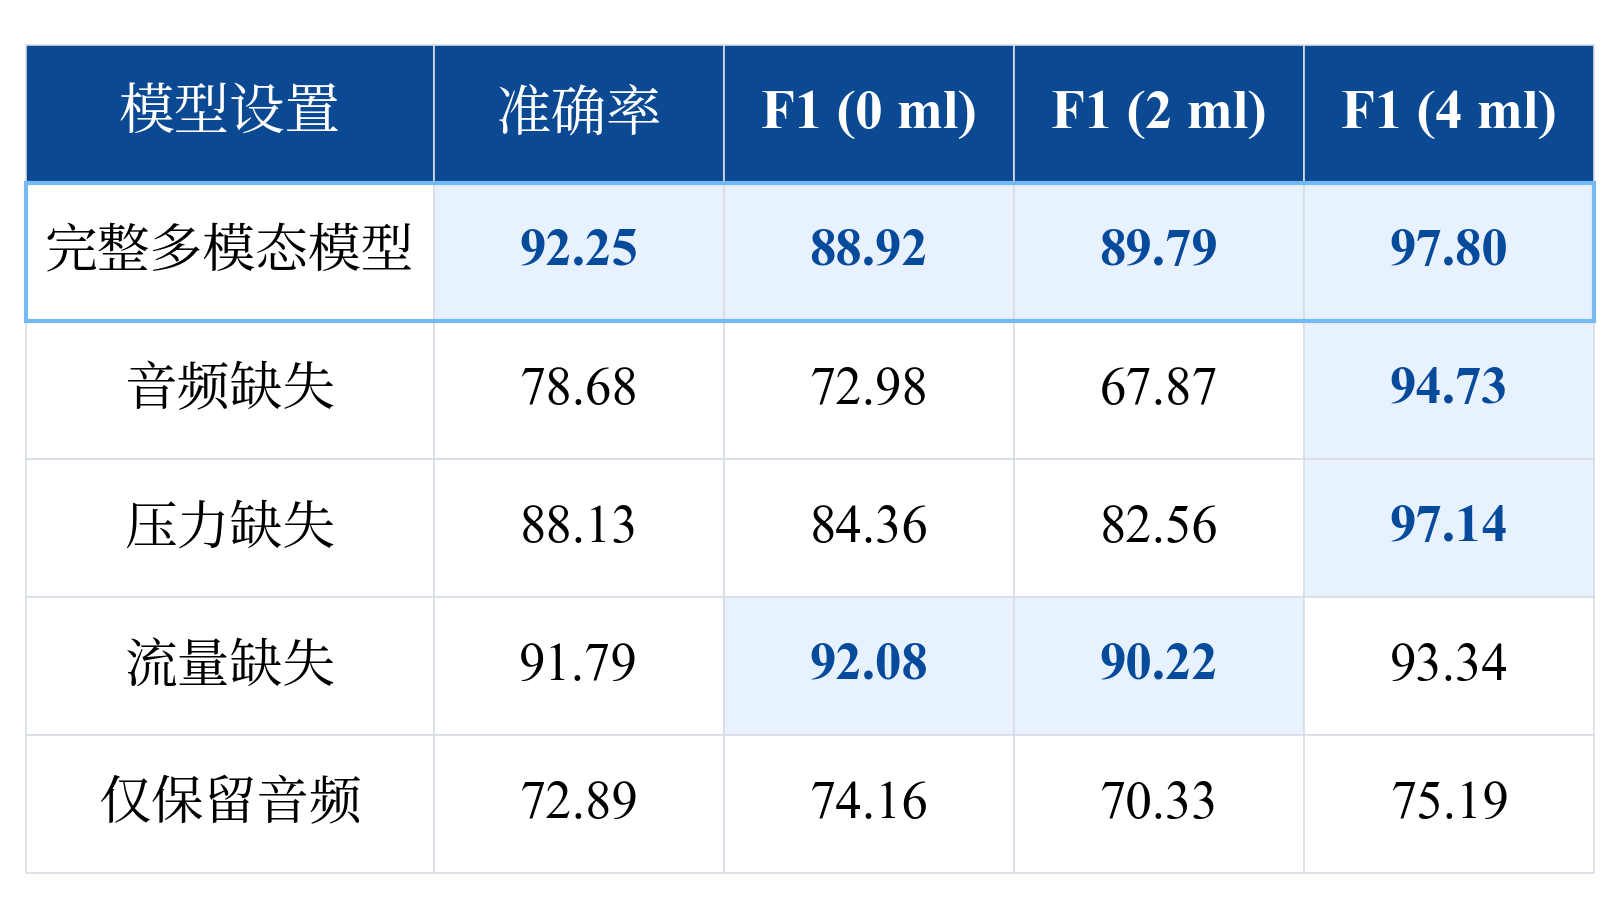

,模型设置,准确率,F1 (0 ml),F1 (2 ml),F1 (4 ml)
0,完整多模态模型,92.25,88.92,89.79,97.80
1,音频缺失,78.68,72.98,67.87,94.73
2,压力缺失,88.13,84.36,82.56,97.14
3,流量缺失,91.79,92.08,90.22,93.34
4,仅保留音频,72.89,74.16,70.33,75.19


In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib import font_manager as fm
from matplotlib.patches import Rectangle


def find_thesis_dir() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd / "thesis", cwd.parent / "thesis"]
    for candidate in candidates:
        if (candidate / "4.3.md").exists() and (candidate / "fonts" / "NotoSerifCJKsc-Regular.otf").exists():
            return candidate.resolve()
    raise FileNotFoundError("Cannot find thesis/4.3.md and thesis/fonts/NotoSerifCJKsc-Regular.otf")


THESIS_DIR = find_thesis_dir()
MD_PATH = THESIS_DIR / "4.3.md"
FONT_PATH = THESIS_DIR / "fonts" / "NotoSerifCJKsc-Regular.otf"
TIMES_FONT_PATH = Path("/mnt/c/Windows/Fonts/times.ttf")
TIMES_BOLD_FONT_PATH = Path("/mnt/c/Windows/Fonts/timesbd.ttf")
if not TIMES_FONT_PATH.exists():
    TIMES_FONT_PATH = THESIS_DIR / "fonts" / "LiberationSerif-Regular.ttf"
if not TIMES_BOLD_FONT_PATH.exists():
    TIMES_BOLD_FONT_PATH = TIMES_FONT_PATH

fm.fontManager.addfont(str(FONT_PATH))
fm.fontManager.addfont(str(TIMES_FONT_PATH))
fm.fontManager.addfont(str(TIMES_BOLD_FONT_PATH))
CN_FONT_NAME = fm.FontProperties(fname=str(FONT_PATH)).get_name()
EN_FONT_NAME = fm.FontProperties(fname=str(TIMES_FONT_PATH)).get_name()
CN_FP = fm.FontProperties(fname=str(FONT_PATH), size=38)
CN_FP_HEADER = fm.FontProperties(fname=str(FONT_PATH), size=40, weight="bold")
CN_FP_BOLD = fm.FontProperties(fname=str(FONT_PATH), size=38, weight="bold")
EN_FP = fm.FontProperties(fname=str(TIMES_FONT_PATH), size=38)
EN_FP_HEADER = fm.FontProperties(fname=str(TIMES_BOLD_FONT_PATH), size=40, weight="bold")
EN_FP_BOLD = fm.FontProperties(fname=str(TIMES_BOLD_FONT_PATH), size=38, weight="bold")

plt.rcParams.update({
    "font.family": [EN_FONT_NAME, CN_FONT_NAME],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


def clean_cell(value: str) -> str:
    return value.strip().strip("`").replace("\\%", "%")


def contains_cjk(value: object) -> bool:
    return any("一" <= ch <= "鿿" for ch in str(value))


def font_for(value: object, *, header: bool = False, bold: bool = False) -> fm.FontProperties:
    if contains_cjk(value):
        if header:
            return CN_FP_HEADER
        return CN_FP_BOLD if bold else CN_FP
    if header:
        return EN_FP_HEADER
    return EN_FP_BOLD if bold else EN_FP


def extract_markdown_table(title_prefix: str) -> pd.DataFrame:
    lines = MD_PATH.read_text(encoding="utf-8").splitlines()
    title_idx = next(i for i, line in enumerate(lines) if line.strip().startswith(title_prefix))
    table_start = next(i for i in range(title_idx + 1, len(lines)) if lines[i].lstrip().startswith("|"))
    table_lines = []
    for line in lines[table_start:]:
        if not line.lstrip().startswith("|"):
            break
        table_lines.append(line.strip())

    header = [clean_cell(cell) for cell in table_lines[0].strip("|").split("|")]
    rows = []
    for raw in table_lines[2:]:
        cells = [clean_cell(cell) for cell in raw.strip("|").split("|")]
        if len(cells) == len(header):
            rows.append(cells)
    return pd.DataFrame(rows, columns=header)


def fmt_number(value: str | float) -> str:
    if isinstance(value, str):
        value = value.strip().strip("`")
    return f"{float(value):.2f}"


def draw_metric_table(
    df: pd.DataFrame,
    output_stem: str,
    highlight_label: str = "完整多模态模型",
    extra_highlight_values: set[str] | None = None,
) -> None:
    extra_highlight_values = extra_highlight_values or set()
    fig_w = 16.0
    fig_h = 9.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.axis("off")

    col_widths = [0.26] + [0.185] * (len(df.columns) - 1)
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=col_widths,
        bbox=[0.01, 0.04, 0.98, 0.92],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(38)

    header_blue = "#0b4a93"
    pale_blue = "#e8f2ff"
    grid = "#d8dde5"
    text_blue = "#064a9b"
    highlight_edge = "#75b9f2"

    numeric_cols = list(df.columns[1:])
    numeric_values = df[numeric_cols].astype(float)
    column_max = numeric_values.max(axis=0)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor(grid)
        cell.set_linewidth(1.2)
        cell_value = df.columns[col_idx] if row_idx == 0 else df.iloc[row_idx - 1, col_idx]
        is_framed_row = row_idx > 0 and str(df.iloc[row_idx - 1, 0]) == highlight_label
        is_painted_cell = False
        cell.get_text().set_fontproperties(font_for(cell_value, bold=is_framed_row))
        if row_idx == 0:
            cell.set_facecolor(header_blue)
            cell.get_text().set_color("white")
            cell.get_text().set_fontproperties(font_for(cell_value, header=True))
        else:
            cell.set_facecolor("white")
            if col_idx > 0:
                col_name = df.columns[col_idx]
                value = float(df.iloc[row_idx - 1, col_idx])
                is_painted_cell = abs(value - float(column_max[col_name])) < 1e-9 or fmt_number(value) in extra_highlight_values
                if is_painted_cell:
                    cell.set_facecolor(pale_blue)
                    cell.get_text().set_color(text_blue)
                    cell.get_text().set_fontproperties(font_for(cell_value, bold=True))
            if is_framed_row and not is_painted_cell:
                cell.get_text().set_fontproperties(font_for(cell_value, bold=True))

    fig.canvas.draw()
    highlight_matches = df.index[df.iloc[:, 0].eq(highlight_label)].tolist()
    if highlight_matches:
        table_row = highlight_matches[0] + 1
        first = table[(table_row, 0)]
        last = table[(table_row, len(df.columns) - 1)]
        x0, y0 = first.get_x(), first.get_y()
        x1 = last.get_x() + last.get_width()
        h = first.get_height()
        ax.add_patch(
            Rectangle(
                (x0, y0),
                x1 - x0,
                h,
                fill=False,
                edgecolor=highlight_edge,
                linewidth=3.0,
                transform=ax.transAxes,
                zorder=10,
            )
        )

    for suffix in (".png",):
        fig.savefig(THESIS_DIR / f"{output_stem}{suffix}", dpi=300, facecolor="white")
    display(fig)
    plt.close(fig)


table43 = extract_markdown_table("表 4.3")
display_names = {
    "完整多模态模型": "完整多模态",
    "音频缺失": "去除音频",
    "压力缺失": "去除压力",
    "流量缺失": "去除流量",
    "仅保留音频": "Audio-only",
}

rows = []
for display_name, md_model_name in display_names.items():
    subset = table43[table43["模型设置"].eq(md_model_name)]
    if subset.empty:
        raise ValueError(f"4.3.md 表 4.3 中找不到模型设置：{md_model_name}")
    by_class = subset.set_index("类别")
    rows.append({
        "模型设置": display_name,
        "准确率": fmt_number(subset.iloc[0]["Accuracy [%]"]),
        "F1 (0 ml)": fmt_number(by_class.loc["0 ml", "F1-Score [%]"]),
        "F1 (2 ml)": fmt_number(by_class.loc["2 ml", "F1-Score [%]"]),
        "F1 (4 ml)": fmt_number(by_class.loc["4 ml", "F1-Score [%]"]),
    })

missing_modality_df = pd.DataFrame(rows)
draw_metric_table(missing_modality_df, "f1_table_result", extra_highlight_values={"88.92", "89.79", "94.73", "97.14"})
missing_modality_df


![缺失模态结果表](f1_table_result.png)

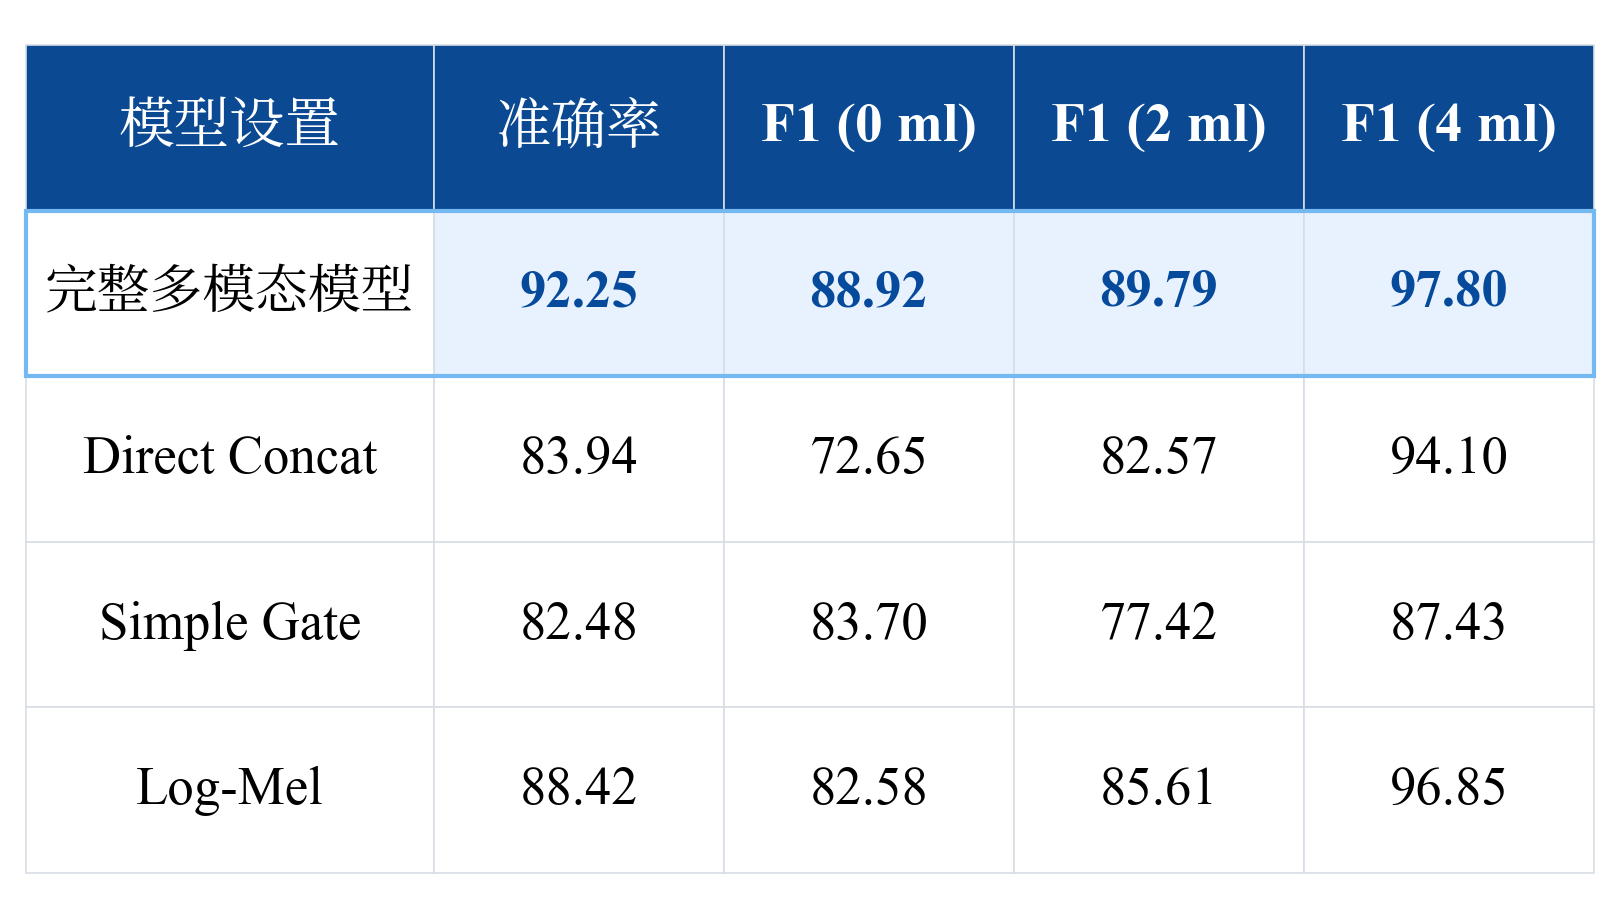

,模型设置,准确率,F1 (0 ml),F1 (2 ml),F1 (4 ml),4.3.md 准确率,差值 准确率,4.3.md F1 (0 ml),差值 F1 (0 ml),4.3.md F1 (2 ml),差值 F1 (2 ml),4.3.md F1 (4 ml),差值 F1 (4 ml)
0,完整多模态模型,92.25,88.92,89.79,97.80,92.25,+0.00,88.92,+0.00,89.79,+0.00,97.80,+0.00
1,Direct Concat,83.94,72.65,82.57,94.10,83.58,+0.36,75.96,-3.31,68.21,+14.36,80.59,+13.51
2,Simple Gate,82.48,83.70,77.42,87.43,83.21,-0.73,83.70,+0.00,77.42,+0.00,87.43,+0.00
3,Log-Mel,88.42,82.58,85.61,96.85,89.88,-1.46,82.58,+0.00,85.61,+0.00,96.85,+0.00


In [6]:
target_ablation_df = pd.DataFrame([
    {"模型设置": "完整多模态模型", "准确率": "92.25", "F1 (0 ml)": "88.92", "F1 (2 ml)": "89.79", "F1 (4 ml)": "97.80"},
    {"模型设置": "Direct Concat", "准确率": "83.94", "F1 (0 ml)": "72.65", "F1 (2 ml)": "82.57", "F1 (4 ml)": "94.10"},
    {"模型设置": "Simple Gate", "准确率": "82.48", "F1 (0 ml)": "83.70", "F1 (2 ml)": "77.42", "F1 (4 ml)": "87.43"},
    {"模型设置": "Log-Mel", "准确率": "88.42", "F1 (0 ml)": "82.58", "F1 (2 ml)": "85.61", "F1 (4 ml)": "96.85"},
])

table44 = extract_markdown_table("表 4.4")
table44_model_map = {
    "完整多模态模型": "HCAF-PCEN-DualXAttn",
    "Direct Concat": "Direct Concat",
    "Simple Gate": "Simple Gate",
    "Log-Mel": "Log-Mel 96",
}

parsed_rows = []
for display_name, md_model_name in table44_model_map.items():
    subset = table44[table44["模型设置"].eq(md_model_name)]
    if subset.empty:
        raise ValueError(f"4.3.md 表 4.4 中找不到模型设置：{md_model_name}")
    by_class = subset.set_index("类别")
    parsed_rows.append({
        "模型设置": display_name,
        "准确率": fmt_number(subset.iloc[0]["Accuracy [%]"]),
        "F1 (0 ml)": fmt_number(by_class.loc["0 ml", "F1-Score [%]"]),
        "F1 (2 ml)": fmt_number(by_class.loc["2 ml", "F1-Score [%]"]),
        "F1 (4 ml)": fmt_number(by_class.loc["4 ml", "F1-Score [%]"]),
    })

ablation_from_43md_df = pd.DataFrame(parsed_rows)
metric_cols = ["准确率", "F1 (0 ml)", "F1 (2 ml)", "F1 (4 ml)"]
comparison = target_ablation_df.copy()
for col in metric_cols:
    target = target_ablation_df[col].astype(float)
    parsed = ablation_from_43md_df[col].astype(float)
    comparison[f"4.3.md {col}"] = parsed.map(lambda x: f"{x:.2f}")
    comparison[f"差值 {col}"] = (target - parsed).map(lambda x: f"{x:+.2f}")

comparison.to_csv(THESIS_DIR / "ablation_vs_4_3md_comparison.csv", index=False, encoding="utf-8-sig")
draw_metric_table(target_ablation_df, "ablation_table_result")
comparison


![消融实验结果表](ablation_table_result.png)